<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Gold_Nanocluster_Simulation_of_Rabi_Oscillations_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

## Gold-Nanocluster Simulation Parameters

### Parameter and Symbol Definitions
| Symbol | Definition |
| :--- | :--- |
| RWA | Rotating-Wave Approximation |
| DOCP | Degree of Circular Polarization |
| $\mu\text{s}$ | Microseconds |
| MHz | Megahertz |
| rad | Radians |
| $H$ | System Hamiltonian |
| $\hbar$ | Reduced Planck constant |
| $\delta$ | Static detuning |
| $\Omega_x$, $\Omega_y$ | Rabi frequencies along the x and y axes |
| $\sigma_x$, $\sigma_y$, $\sigma_z$ | Pauli matrices |
| $\sigma_+$, $\sigma_-$ | Raising and lowering operators |
| $T_1$ | Longitudinal relaxation time |
| $T_2$ | Transverse relaxation time |
| $P_{\text{thermal}}$ | Thermal equilibrium polarization |
| $\Gamma_{\text{down}}$, $\Gamma_{\text{up}}$ | Incoherent relaxation rates |
| $\Gamma_{\phi}$ | Pure dephasing rate |

### Physical Scope
This Colab notebook provides a theoretical investigation of a gold-nanocluster system treated as an isolated, controllable effective two-level system. Existing literature details ensemble magneto-optical spectroscopy, necessitating the direct assumption of an isolated Zeeman doublet facilitating qubit modeling. Effective $g$-values derived from optical spectra act as proxies, operating independently of an identified qubit transition frequency. Atomistic Hamiltonians, ligand vibrations, multilevel leakage, measured oscillator strengths, and calibrated spin-photon selection rules are omitted from the current system definitions. A narrow Gaussian distribution models an assumed selected subensemble, diverging from the experimentally established linewidths of macroscopic films or solutions.

### System Model
The physical model employs the Rotating-Wave Approximation (RWA) defining the temporal evolution of the selected Zeeman doublet. Time units are defined in microseconds ($\mu\text{s}$), cyclic frequencies in megahertz (MHz), and angular frequencies in radians per microsecond (rad/$\mu\text{s}$). System dynamics are governed by the specific Hamiltonian:
$$\frac{H}{\hbar}=\frac{1}{2}\left(\delta\sigma_z+\Omega_x\sigma_x+\Omega_y\sigma_y\right)$$
Excited states correspond to the QuTiP basis vector $\vert{}2,0\rangle$, possessing an eigenvalue $\sigma_z=+1$. Environmental coupling induces thermal transitions that satisfy detailed balance for the assigned states.

### Relaxation and Readout Dynamics
Associated relaxation and dephasing rates are defined mathematically:
$$\Gamma_{\text{down}}=\frac{1+P_{\text{thermal}}}{2T_1}$$
$$\Gamma_{\text{up}}=\frac{1-P_{\text{thermal}}}{2T_1}$$
$$\Gamma_{\phi}=\frac{1}{T_2}-\frac{1}{2T_1}$$
Open quantum systems evolve according to a Lindblad master equation incorporating the specific collapse operators $\sqrt{\Gamma_{\text{down}}}\sigma_{-}$, $\sqrt{\Gamma_{\text{up}}}\sigma_{+}$, and $\sqrt{\Gamma_{\phi}/2}\sigma_z$. Photon statistics rely on independent preparations coupled with a hypothetical state-dependent Poisson readout mechanism. Experimental variables including absolute photon counts, collection efficiency, and readout contrast act as assumed parameters, operating independently of the macroscopic Degree of Circular Polarization (DOCP) measurements. Each independent counting trial samples the defined detuning distribution, maintaining fixed offsets confined within its respective pulse sequence.

### Computational Methodology
CuPy batches affine Bloch propagators, accelerating the Lindblad trajectory calculations on a graphical processing unit. QuTiP independently evaluates selected density-matrix trajectories on the central processing unit, bypassing sparse solver routines for these specific $2\times2$ density matrices. Gaussian static detuning distributions are integrated via Gauss-Hermite quadrature. Simulated finite square pulses incorporate both dissipation and defined detuning parameters continuously. Static offsets persist during each specific pulse sequence, permitting spin echo techniques to refocus those parameters subject to finite-pulse errors.

### Data Handling and Visualization
Repeated measurements of a singular emitter with permanently fixed detuning dictate setting the distribution width precisely to zero. In this way, the simulation architecture omits correlated drift and technical detector noise entirely. Visual plots render directly into PNG byte streams in memory at 250 DPI, eliminating local file writing. Rendered image bytes and numerical results persist in memory, ensuring immediate availability for subsequent notebook cells. This memory-centric approach promotes rapid iteration, mitigating I/O bottlenecks during extensive parameter sweeps.

### Primary References
*   Smith et al., *J. Phys. Chem. Lett.* 16, 5168-5172 (2025): [https://doi.org/10.1021/acs.jpclett.5c00723](https://doi.org/10.1021/acs.jpclett.5c00723)
*   Foxley et al., *ACS Central Science* 11, 1329-1335 (2025): [https://doi.org/10.1021/acscentsci.5c00139](https://doi.org/10.1021/acscentsci.5c00139)
*   Molecular coherent-control precedent: [https://doi.org/10.1126/science.abb9352](https://doi.org/10.1126/science.abb9352)
*   QuTiP Dynamics Documentation: [https://qutip.readthedocs.io/en/stable/guide/dynamics/dynamics-master.html](https://qutip.readthedocs.io/en/stable/guide/dynamics/dynamics-master.html)
*   CuPy Matrix Multiplication Documentation: [https://docs.cupy.dev/en/stable/reference/generated/cupy.matmul.html](https://docs.cupy.dev/en/stable/reference/generated/cupy.matmul.html)

Preparing dependencies for the simulation worker...
GPU check passed: b'Tesla T4' CuPy 14.0.1, CUDA runtime 13000
Backend: CuPy GPU; QuTiP 5.3.1
CONDITIONAL MODEL: Au25_PET, B=17.5 T, T=5 K
Optical-fit g proxy=1.1; hypothetical f01=269.428 GHz
Assumed T1=10 us, T2=2 us; thermal polarization=0.8599
The optical-fit g does not identify a measured qubit transition.
This Zeeman proxy lies above 100 GHz: ordinary few-GHz drive hardware
would not address it directly. No optical Raman protocol is assumed.
Computing ensemble Rabi and Ramsey scans...


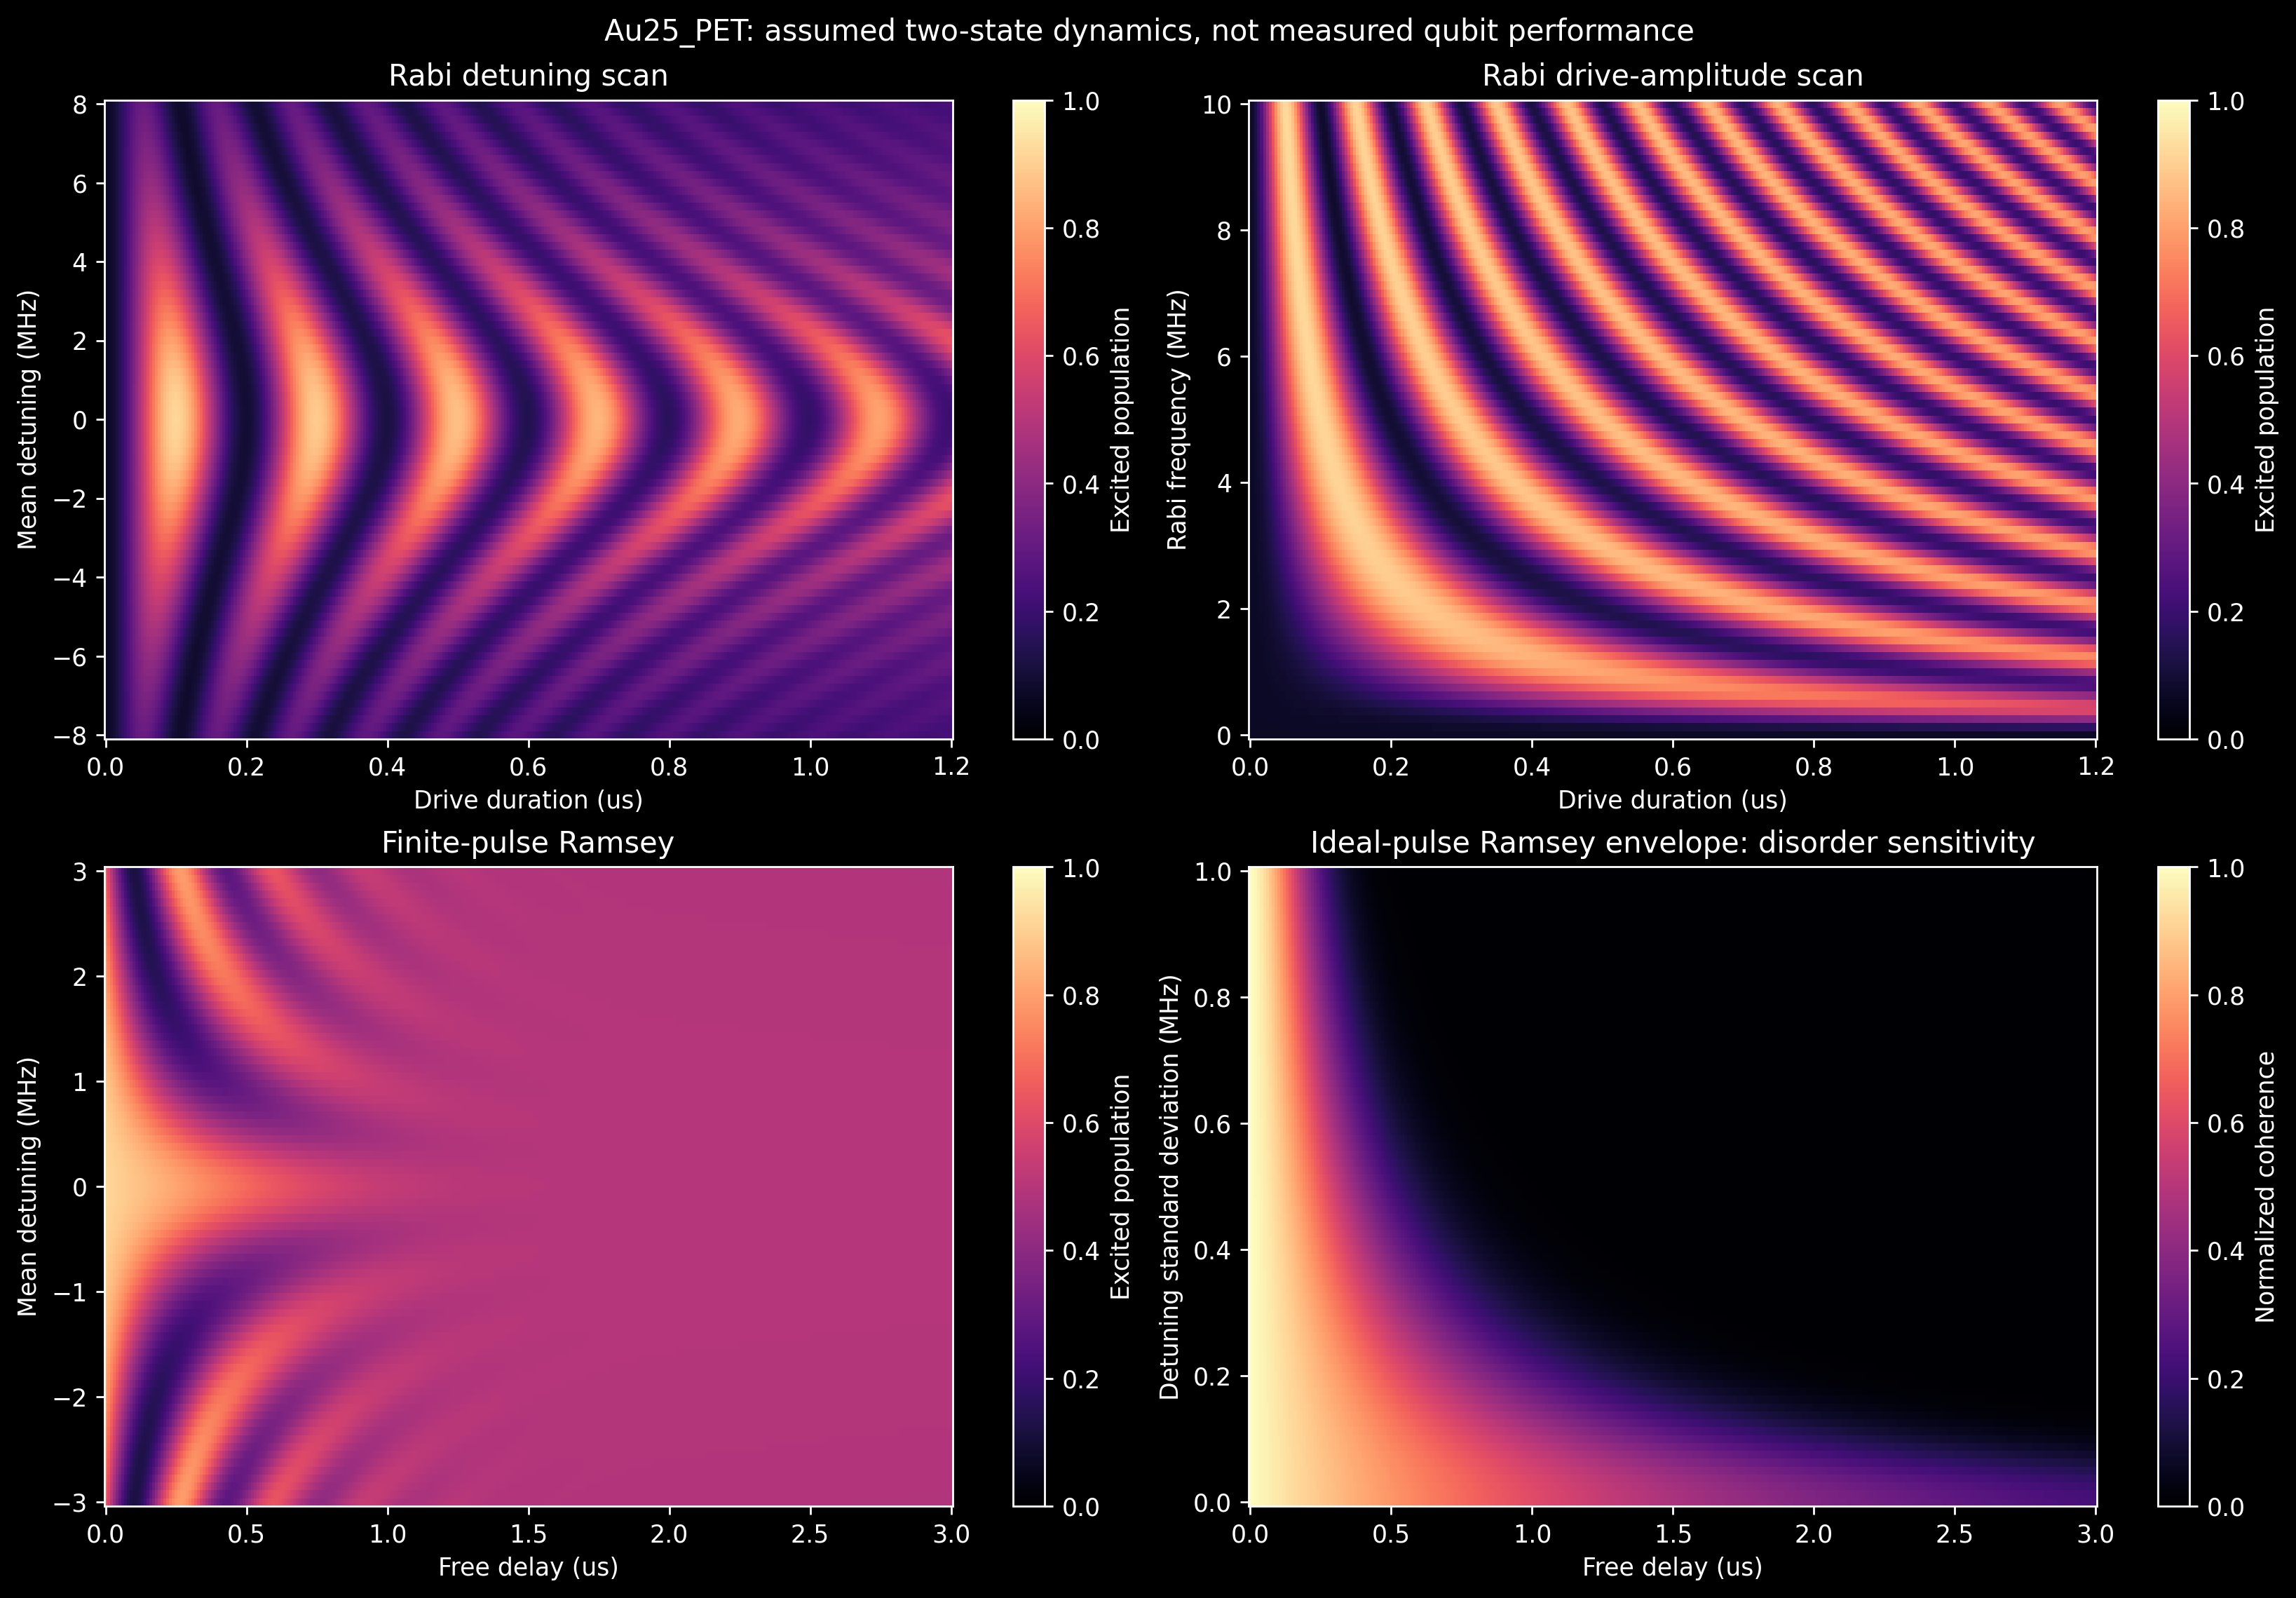

Checking finite-pulse dynamics against QuTiP...
QuTiP maximum errors: Rabi 5.46e-09; Ramsey 9.56e-11


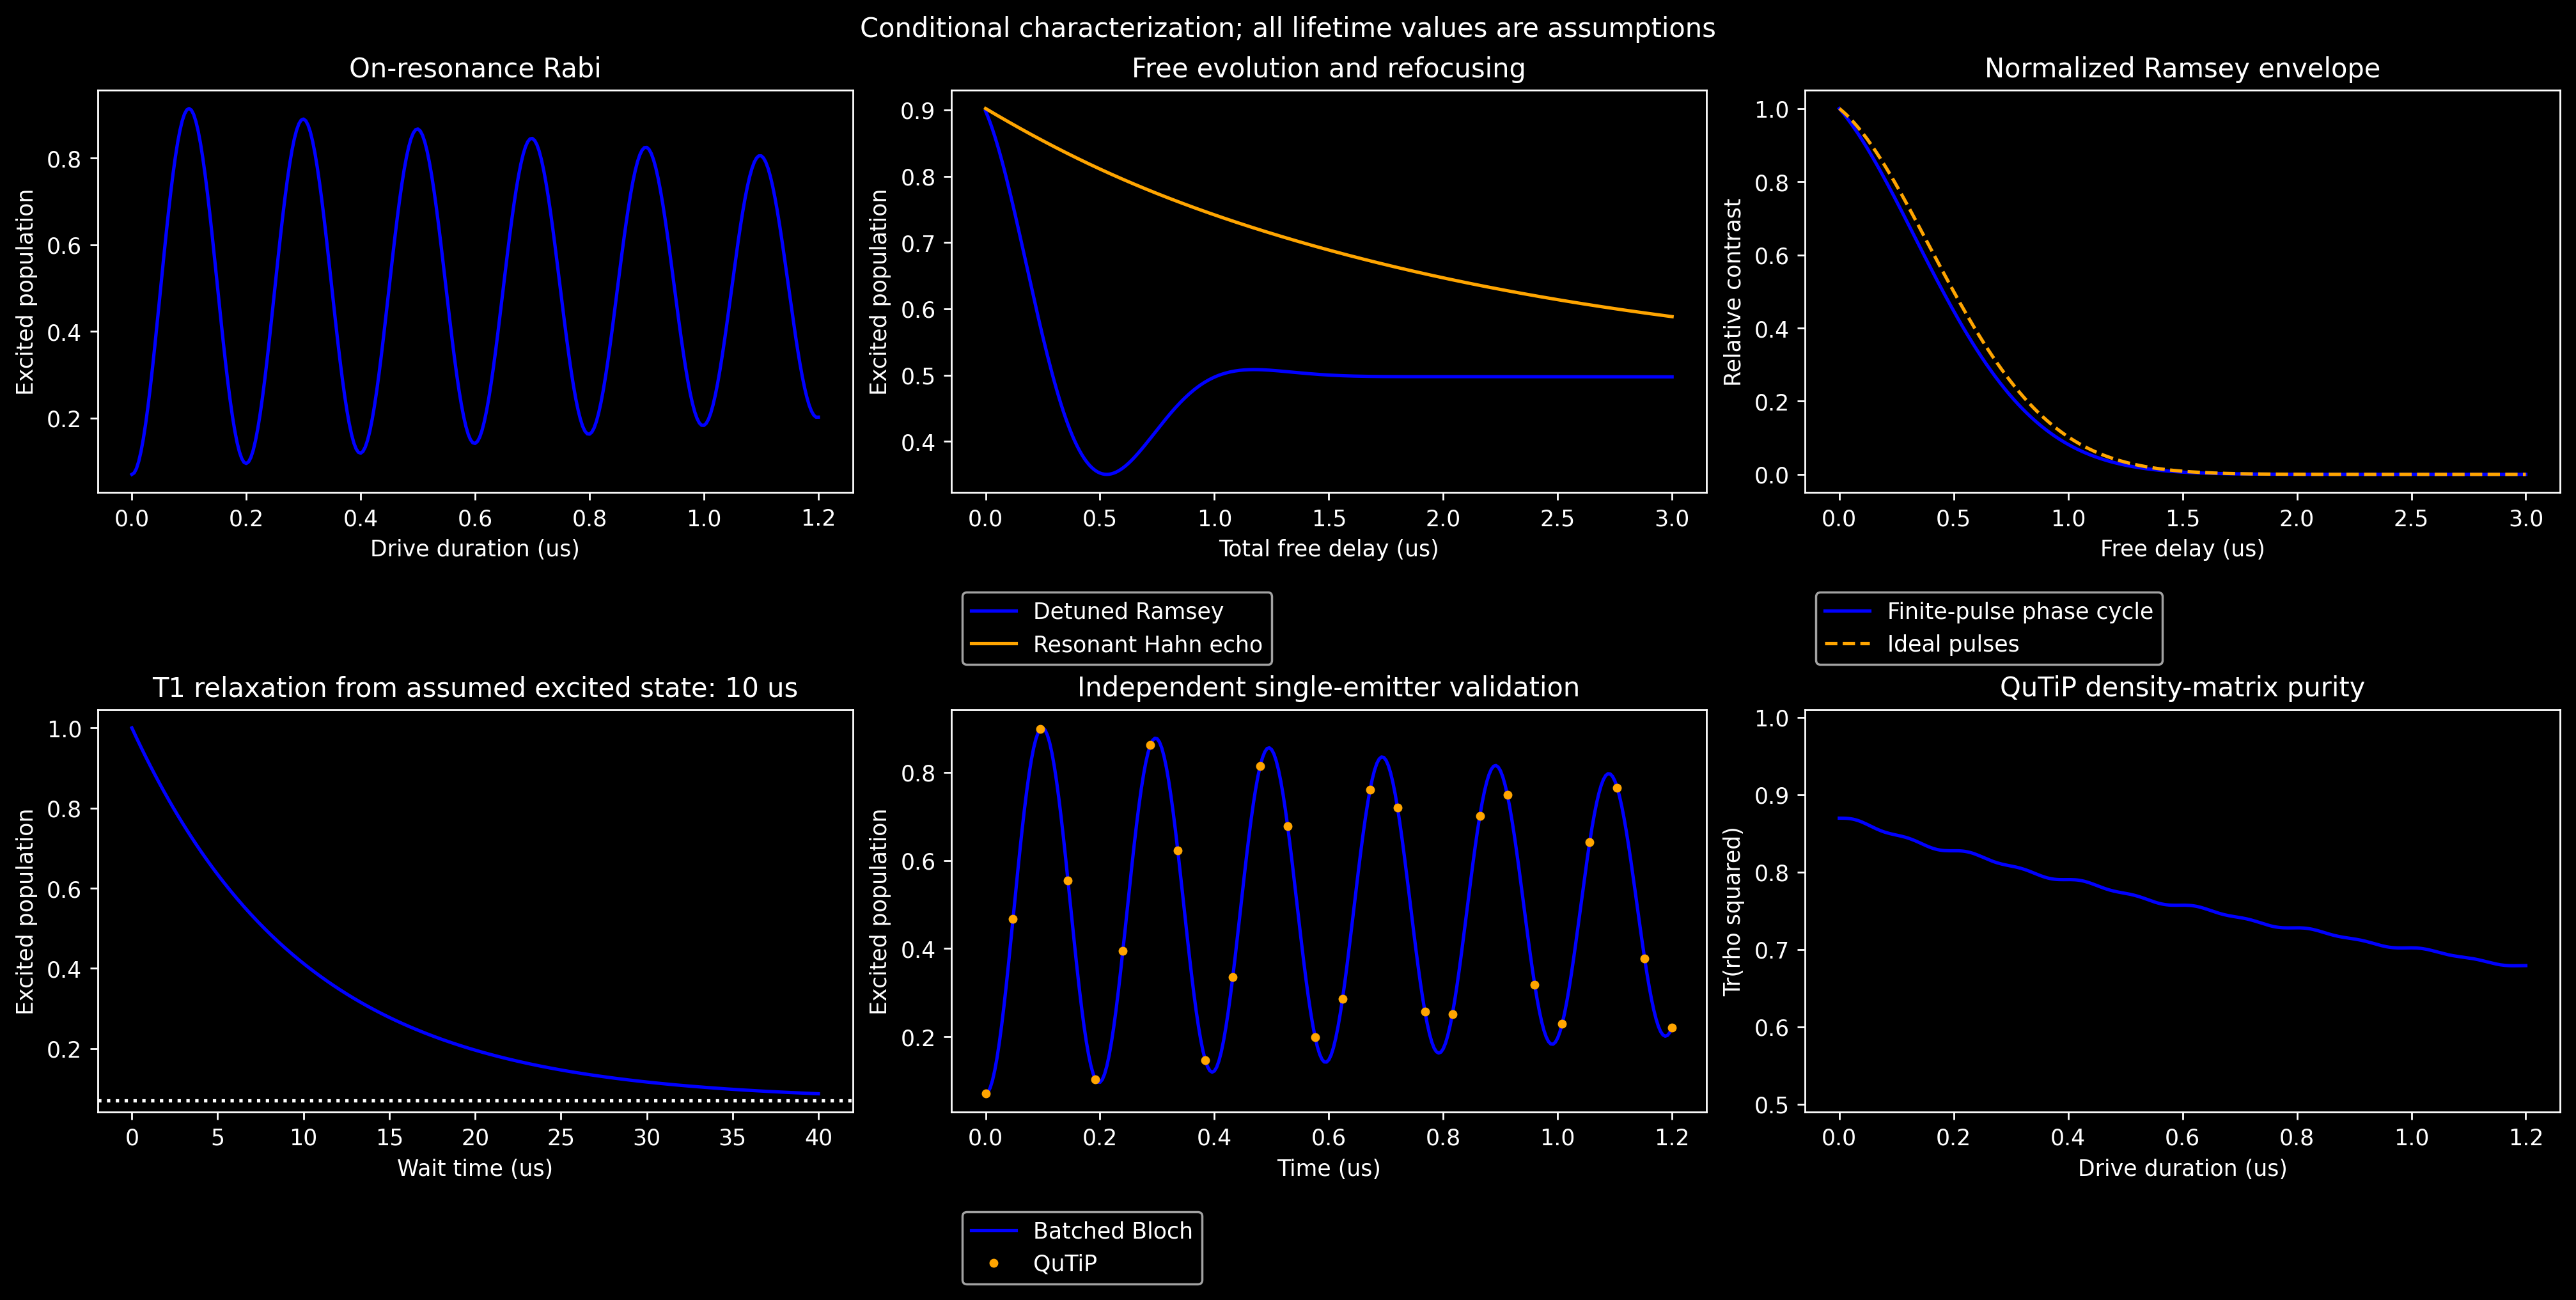

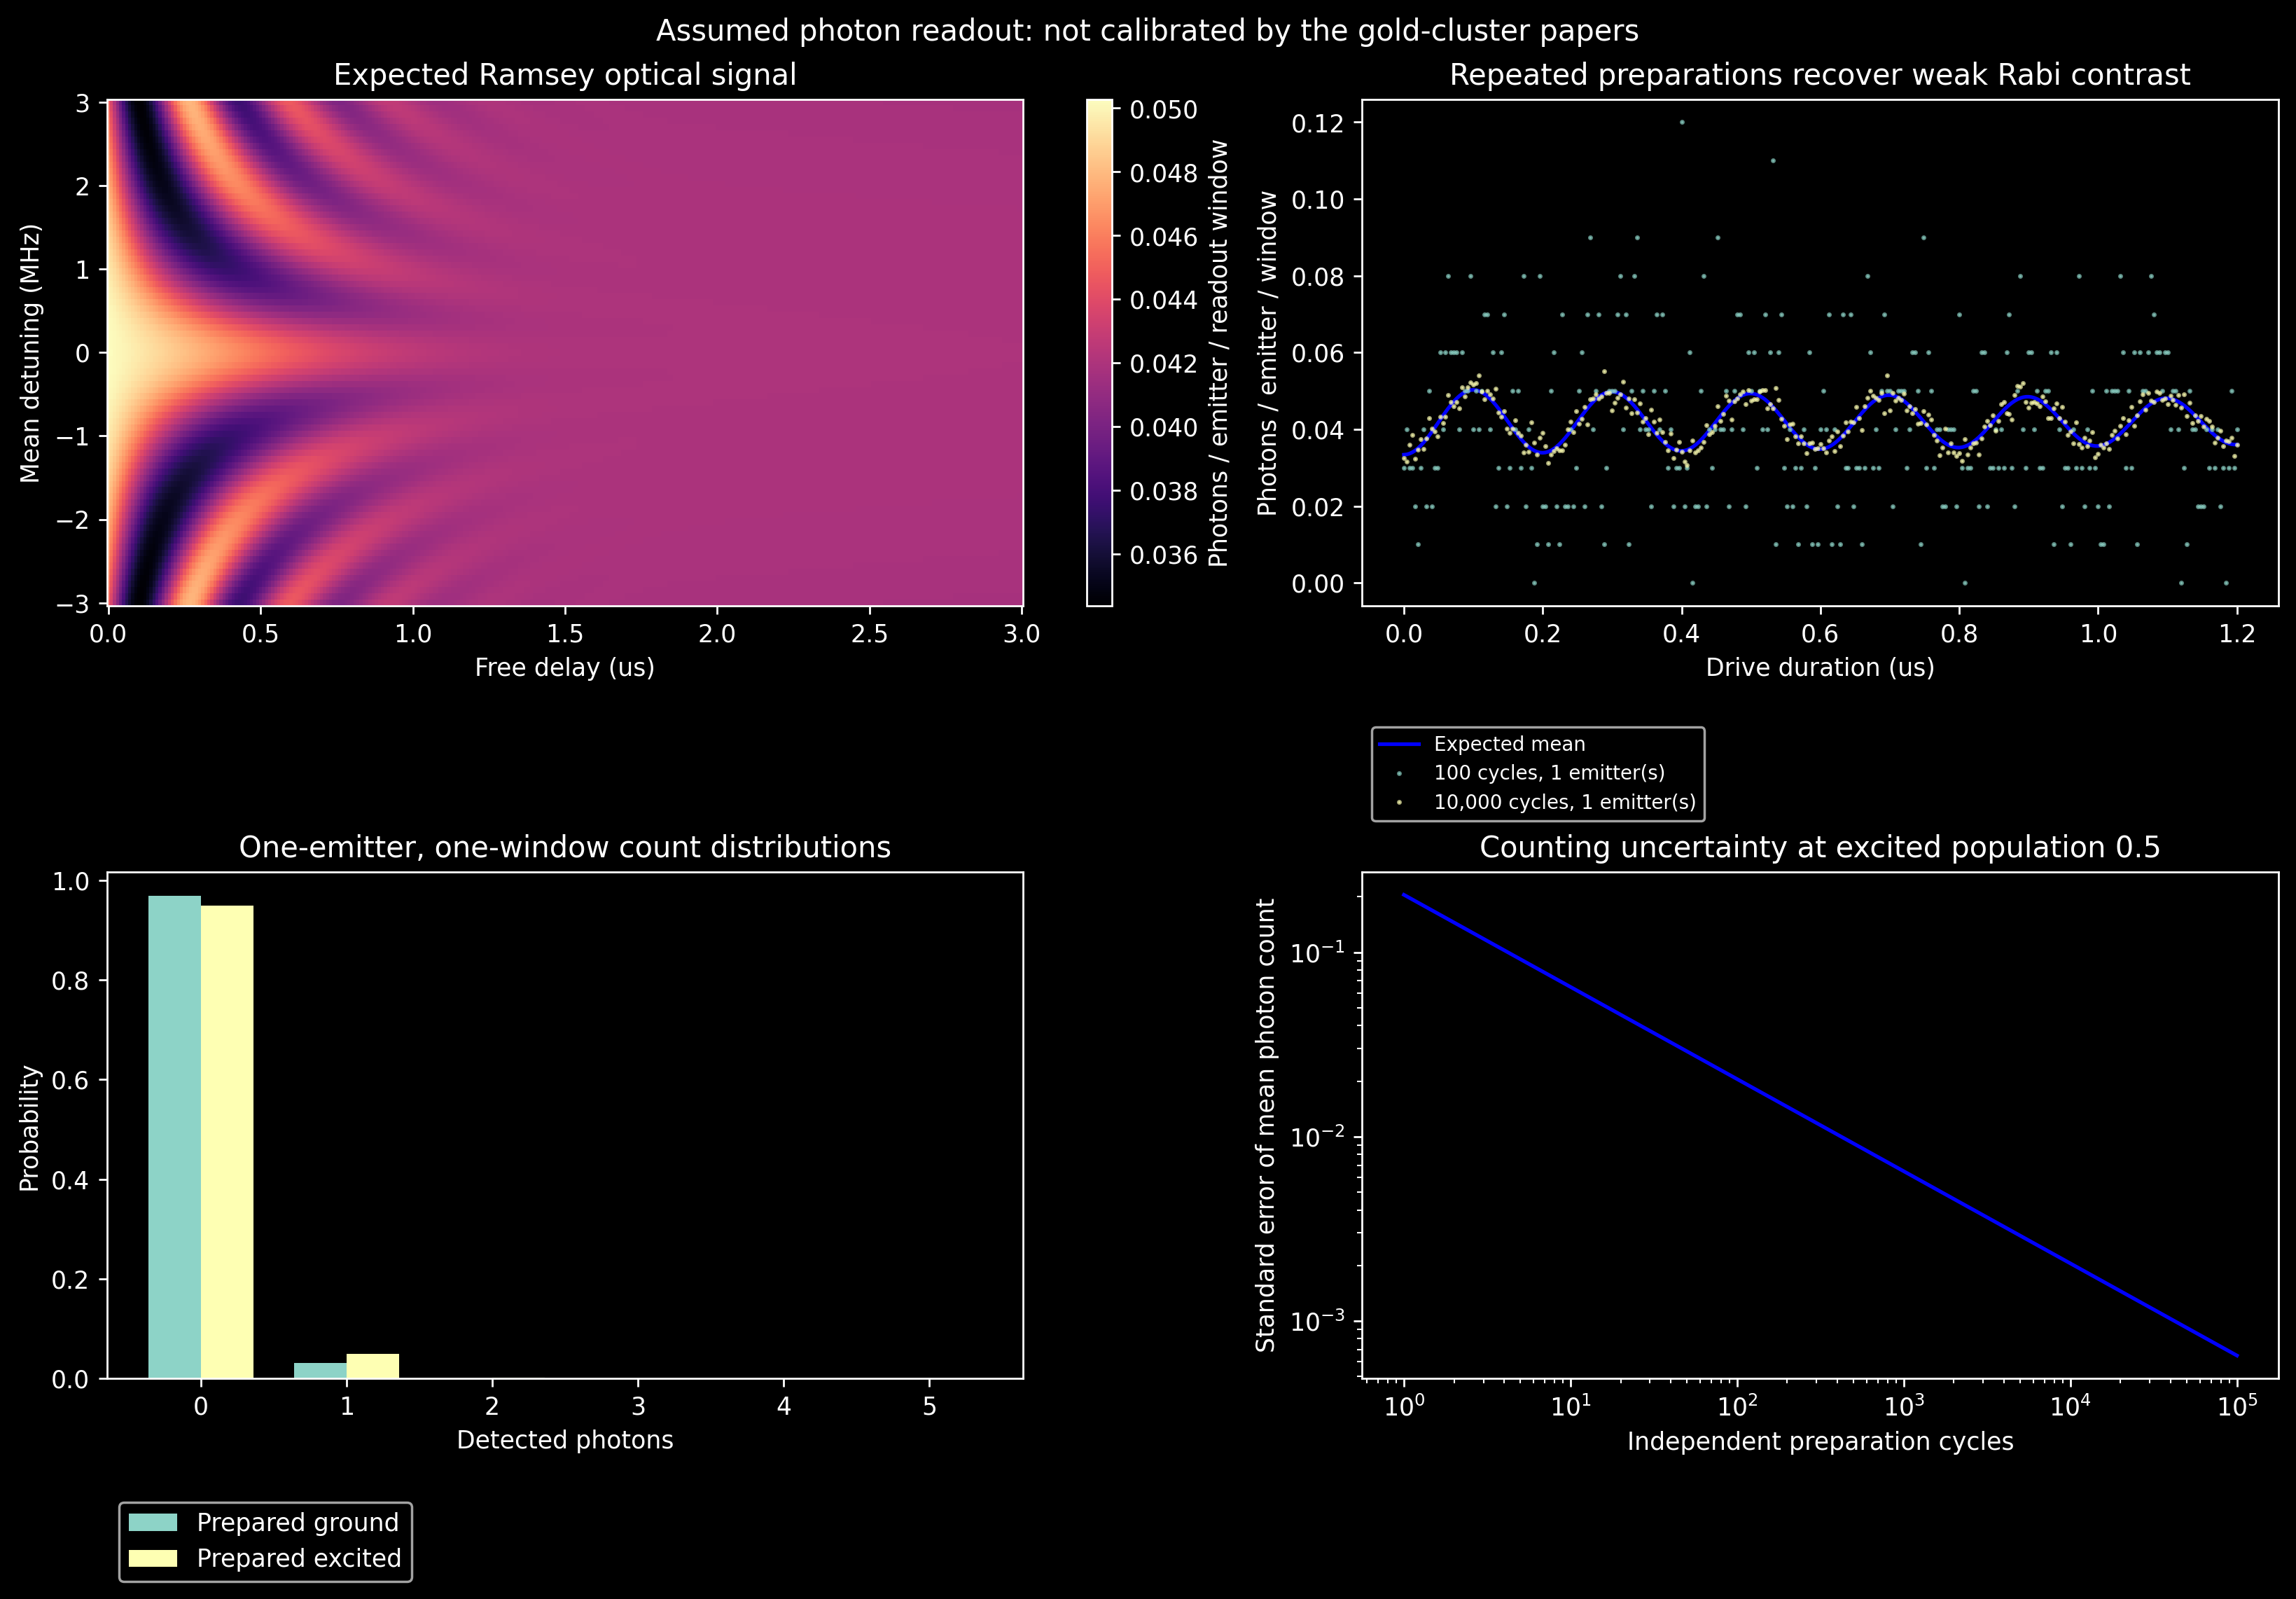

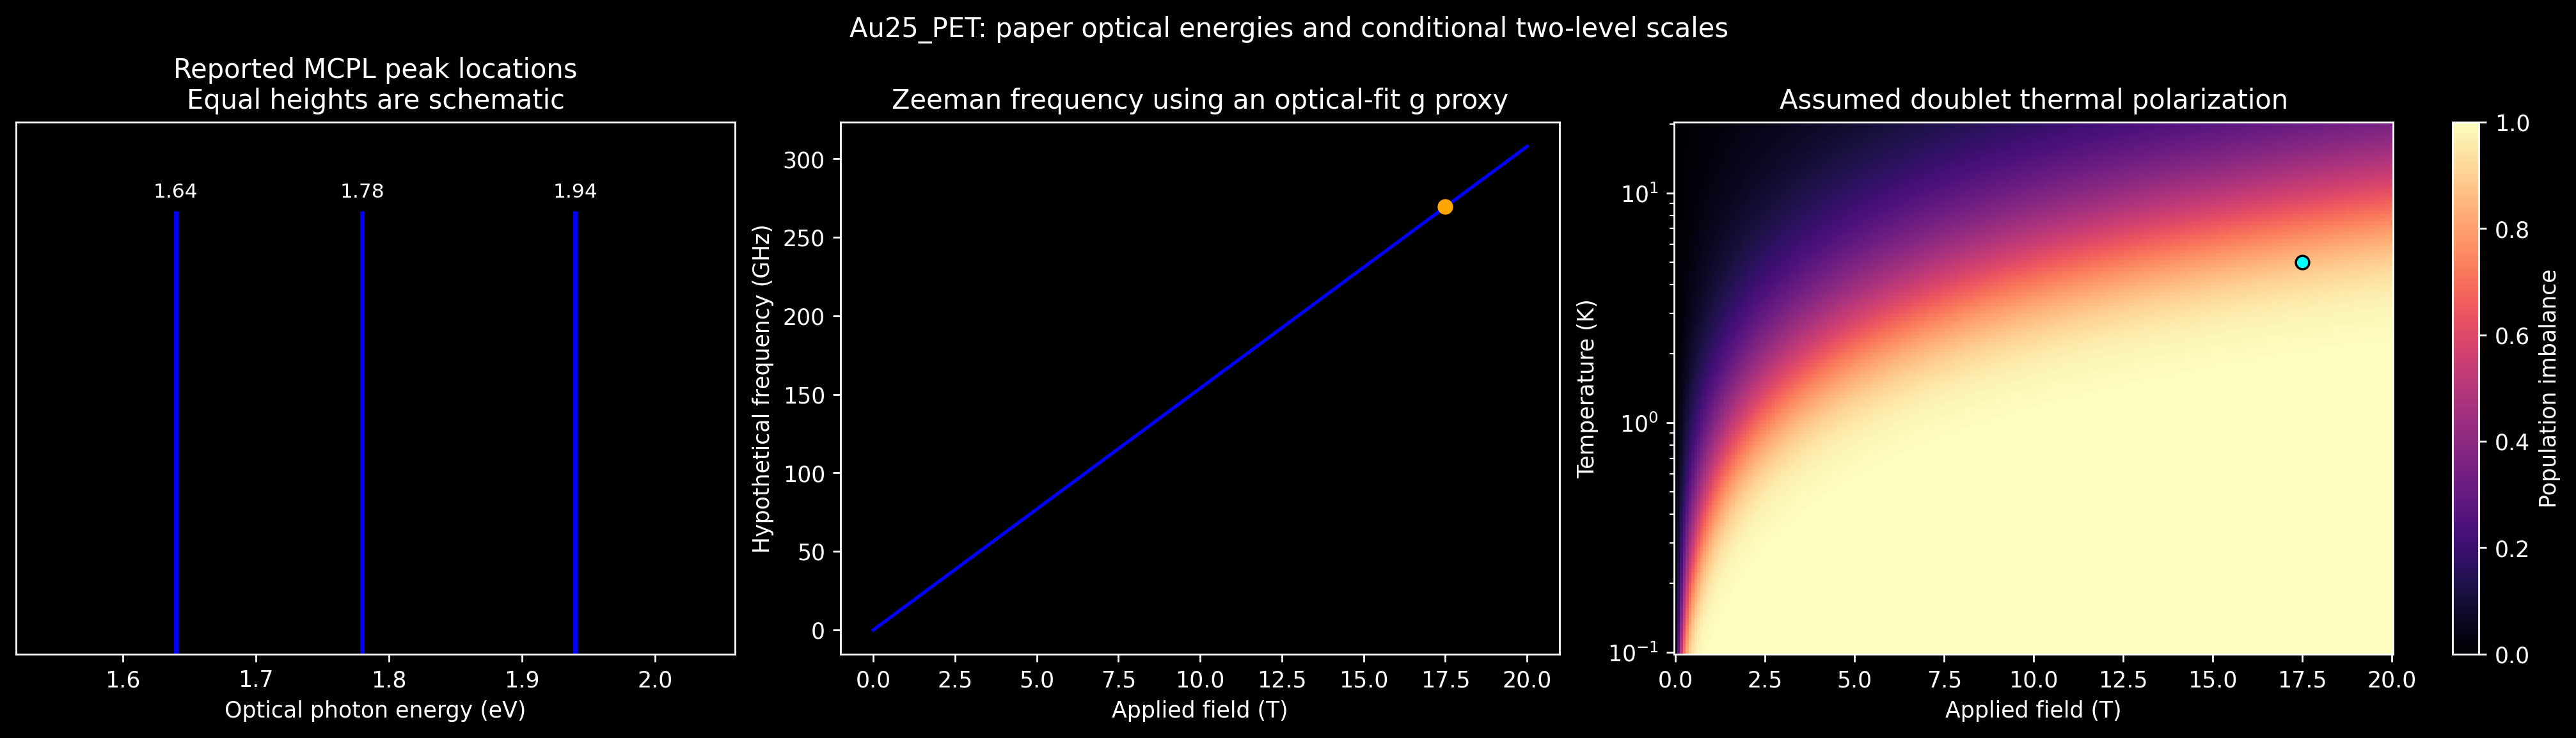

Completed in 10.60 s; figures retained in FIGURE_BYTES.
Gaussian quadrature error: 2.33e-16
Rabi and Ramsey contrast, photon counts, and lifetimes are conditional assumptions.
No DOCP value was used as a logical-state readout contrast or fidelity.
Ready: 4 in-memory figures and RESULTS.


In [5]:
"""Run a self-contained gold-nanocluster simulation in one Colab cell.
"""

# - Control knobs: paper anchors -
SYSTEM = "Au25_PET"  # Au25_PET, Au25_SC3, or Au144_PET.
FIELD_T = None  # None selects the paper's spectroscopy field.
TEMPERATURE_K = None  # None selects the paper's spectroscopy temperature.
G_EFFECTIVE = None  # None uses an optical-fit g proxy, not a qubit measurement.

# - Control knobs: unmeasured dynamics assumptions -
T1_US = 10.0
T2_US = 2.0  # Homogeneous T2; must not exceed 2*T1.
DETUNING_SIGMA_MHZ = 0.30  # Standard deviation of static ensemble offsets.
RABI_MHZ = 5.0  # On-resonance cyclic Rabi frequency; no power calibration.
RAMSEY_TRACE_DETUNING_MHZ = 0.70
INITIAL_POLARIZATION = None  # None: thermal; otherwise an assumed value [0, 1].
RABI_MAX_US = 1.2
RAMSEY_MAX_US = 3.0
N_TIME = 301
N_SCAN = 81
N_ENSEMBLE = 101  # Increase for long delays or broad detuning distributions.
DETUNING_SPAN_MHZ = 8.0
RAMSEY_SPAN_MHZ = 3.0
MAX_RABI_MHZ = 10.0

# - Control knobs: hypothetical readout and rendering -
PHOTONS_GROUND = 0.030  # Mean detected signal photons per prepared emitter/window.
PHOTONS_EXCITED = 0.050
BACKGROUND_PHOTONS = 0.002
REPETITIONS = (100, 10_000)
EMITTERS_PER_REPETITION = 1  # Independent identical emitters; no superradiance.
RANDOM_SEED = 17
USE_GPU = True
ALLOW_CPU_FALLBACK = False
DPI = 250
VALIDATE_QUTIP = True
VALIDATION_TOLERANCE = 2e-6

# - CUDA stack matching the supplied Colab environment -
CUPY_DISTRIBUTION = "cupy-cuda13x"
CUPY_REQUIREMENT = "cupy-cuda13x==14.0.1"
CUDA_REQUIREMENT = "cuda-toolkit[cublas,cudart,nvrtc]==13.0.2"
CUDA_LIBRARY_MAJOR = 13

# - Self-contained dependency setup -
AUTO_INSTALL = True
FORCE_REINSTALL_CUDA = False  # True reinstalls CUDA component wheels.

import base64
import json
import os
import subprocess
import sys
from collections import deque
from importlib import metadata
from pathlib import Path


def ensure_dependencies():
    """Install required packages without importing them into this kernel."""
    if not AUTO_INSTALL:
        return
    if USE_GPU:
        conda_records = Path(sys.prefix) / "conda-meta"
        if conda_records.exists() and (
            list(conda_records.glob("cupy-*.json"))
            or list(conda_records.glob("cupy-core-*.json"))
        ):
            raise RuntimeError(
                "This installer does not replace Conda-owned CuPy files. "
                "Use a fresh standard Colab GPU runtime for this pip setup."
            )
    print("Preparing dependencies for the simulation worker...", flush=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"],
                   check=True)
    requirements = ["qutip>=5,<6", "scipy", "matplotlib"]
    reinstall = []
    if USE_GPU:
        installed = sorted({
            dist.metadata.get("Name", "").lower().replace("_", "-")
            for dist in metadata.distributions()
            if dist.metadata.get("Name", "").lower().replace("_", "-")
            in {"cupy", "cupy-core"}
            or dist.metadata.get("Name", "").lower().replace("_", "-")
            .startswith("cupy-cuda")
        })
        if installed and installed != [CUPY_DISTRIBUTION]:
            # Shared import namespaces require removing every conflicting wheel.
            subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y",
                            *installed], check=True)
        requirements.extend([CUPY_REQUIREMENT, CUDA_REQUIREMENT])
        expected = {
            "nvidia-cuda-runtime": ["libcudart.so.13"],
            "nvidia-cublas": ["libcublasLt.so.13", "libcublas.so.13"],
            "nvidia-cuda-nvrtc": ["libnvrtc.so.13"],
        }
        for package, sonames in expected.items():
            missing = False
            try:
                dist = metadata.distribution(package)
                paths = [Path(dist.locate_file(item)) for item in dist.files or []]
                for soname in sonames:
                    if not any(path.is_file() and (
                        path.name == soname or path.name.startswith(soname + ".")
                    ) for path in paths):
                        missing = True
            except metadata.PackageNotFoundError:
                missing = True
            if missing or FORCE_REINSTALL_CUDA:
                reinstall.extend(["--reinstall-package", package])
    subprocess.run(
        [sys.executable, "-m", "uv", "pip", "install", "--python",
         sys.executable, *reinstall, *requirements], check=True
    )


SETTINGS = {name: globals()[name] for name in ('SYSTEM', 'FIELD_T', 'TEMPERATURE_K', 'G_EFFECTIVE', 'T1_US', 'T2_US', 'DETUNING_SIGMA_MHZ', 'RABI_MHZ', 'RAMSEY_TRACE_DETUNING_MHZ', 'INITIAL_POLARIZATION', 'RABI_MAX_US', 'RAMSEY_MAX_US', 'N_TIME', 'N_SCAN', 'N_ENSEMBLE', 'DETUNING_SPAN_MHZ', 'RAMSEY_SPAN_MHZ', 'MAX_RABI_MHZ', 'PHOTONS_GROUND', 'PHOTONS_EXCITED', 'BACKGROUND_PHOTONS', 'REPETITIONS', 'EMITTERS_PER_REPETITION', 'RANDOM_SEED', 'USE_GPU', 'ALLOW_CPU_FALLBACK', 'DPI', 'VALIDATE_QUTIP', 'VALIDATION_TOLERANCE', 'CUPY_DISTRIBUTION', 'CUPY_REQUIREMENT', 'CUDA_REQUIREMENT', 'CUDA_LIBRARY_MAJOR', 'AUTO_INSTALL', 'FORCE_REINSTALL_CUDA')}

WORKER_SOURCE = r'''
import base64
import ctypes
import io
import json
import sys
import time
import warnings
from importlib import metadata
from pathlib import Path

# Configuration arrives directly through stdin; no source file is required.
globals().update(json.loads(sys.stdin.read()))

def installed_cupy_packages():
    """Return installed distributions sharing the CuPy import namespace."""
    packages = set()
    for distribution in metadata.distributions():
        name = distribution.metadata.get("Name", "").lower().replace("_", "-")
        if name in {"cupy", "cupy-core"} or name.startswith("cupy-cuda"):
            packages.add(name)
    return sorted(packages)


def preload_cublas():
    """Load CUDA runtime and cuBLAS from explicit Linux wheel paths."""
    global _CUDA_LIBRARY_HANDLES
    if sys.platform != "linux":
        raise RuntimeError("This CUDA setup targets the Linux Colab runtime.")
    _CUDA_LIBRARY_HANDLES = []
    # Load dependencies before dependents and retain the handles.
    libraries = [
        ("nvidia-cuda-runtime", "libcudart"),
        ("nvidia-cublas", "libcublasLt"),
        ("nvidia-cublas", "libcublas"),
    ]
    for package, stem in libraries:
        try:
            distribution = metadata.distribution(package)
        except metadata.PackageNotFoundError as error:
            raise RuntimeError(
                f"{package} is absent. Enable AUTO_INSTALL and run the complete cell."
            ) from error
        paths = [Path(distribution.locate_file(item))
                 for item in distribution.files or []]
        soname = f"{stem}.so.{CUDA_LIBRARY_MAJOR}"
        candidates = sorted(
            (path for path in paths if path.name == soname
             or path.name.startswith(soname + ".")),
            key=lambda path: (path.name != soname, len(path.name)),
        )
        candidates = [path for path in candidates if path.is_file()]
        if not candidates:
            raise RuntimeError(
                f"{soname} is absent from {package}. Reinstall that package "
                "using its version required by cuda-toolkit 13.0.2."
            )
        _CUDA_LIBRARY_HANDLES.append(
            ctypes.CDLL(str(candidates[0].resolve()), mode=ctypes.RTLD_GLOBAL)
        )


def initialize_gpu():
    """Check package identity, resolve cuBLAS, and exercise GPU kernels."""
    installed = installed_cupy_packages()
    if installed != [CUPY_DISTRIBUTION]:
        raise RuntimeError(
            f"Expected only {CUPY_DISTRIBUTION}; found {installed}. "
            "Enable AUTO_INSTALL and run the complete cell."
        )
    preload_cublas()
    import cupy as cp
    import numpy as numpy_reference

    if cp.cuda.runtime.getDeviceCount() < 1:
        raise RuntimeError("Select a Colab GPU runtime.")
    runtime_version = cp.cuda.runtime.runtimeGetVersion()
    if runtime_version // 1000 != CUDA_LIBRARY_MAJOR:
        raise RuntimeError(
            f"Loaded CUDA runtime {runtime_version} does not match CUDA "
            f"{CUDA_LIBRARY_MAJOR}. Check the installed CUDA package versions."
        )
    # Exercise NVRTC elementwise compilation and the batched cuBLAS path.
    sample_cpu = numpy_reference.arange(32, dtype=float).reshape(2, 4, 4) / 32
    sample_gpu = cp.asarray(sample_cpu)
    actual = cp.asnumpy(cp.exp(sample_gpu) @ sample_gpu)
    expected = numpy_reference.exp(sample_cpu) @ sample_cpu
    numpy_reference.testing.assert_allclose(actual, expected, rtol=1e-12,
                                            atol=1e-12)
    cp.cuda.get_current_stream().synchronize()
    print("GPU check passed:", cp.cuda.runtime.getDeviceProperties(0)["name"],
          f"CuPy {cp.__version__}, CUDA runtime {runtime_version}")
    return cp


import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from numpy.polynomial.hermite import hermgauss
from scipy.constants import Boltzmann, physical_constants, h
from scipy.linalg import expm
from scipy.stats import poisson

# - Paper values are separate from assumed control and readout parameters -
PAPER = {
    "Au25_PET": {
        "field": 17.5, "temperature": 5.0, "g_proxy": 1.1,
        "g_uncertainty": 0.1, "optical_ev": [1.64, 1.78, 1.94],
        "max_docp": 0.38, "method": "MCPL",
    },
    "Au25_SC3": {
        "field": 17.5, "temperature": 5.0, "g_proxy": 1.1,
        "g_uncertainty": 0.2, "optical_ev": [1.60, 1.73],
        "max_docp": 0.08, "method": "MCPL",
    },
    "Au144_PET": {
        "field": 10.0, "temperature": 1.6, "g_proxy": 1.6,
        "g_uncertainty": 0.3, "optical_ev": [1.70, 1.80, 1.85, 1.90],
        "max_docp": None, "method": "MCD (selected peaks)",
    },
}


def host(value):
    """Transfer an array to NumPy only at diagnostics or plotting boundaries."""
    return xp.asnumpy(value) if GPU_ACTIVE else np.asarray(value)


def bloch_generator(detuning, drive_x=0.0, drive_y=0.0):
    """Build batched 4x4 affine Bloch generators in inverse microseconds."""
    delta, omega_x, omega_y = xp.broadcast_arrays(
        2 * xp.pi * xp.asarray(detuning, dtype=xp.float64),
        2 * xp.pi * xp.asarray(drive_x, dtype=xp.float64),
        2 * xp.pi * xp.asarray(drive_y, dtype=xp.float64),
    )
    matrix = xp.zeros(delta.shape + (4, 4), dtype=xp.float64)
    matrix[..., 0, 0] = matrix[..., 1, 1] = -1 / T2_US
    matrix[..., 2, 2] = -1 / T1_US
    matrix[..., 0, 1], matrix[..., 1, 0] = -delta, delta
    matrix[..., 0, 2], matrix[..., 2, 0] = omega_y, -omega_y
    matrix[..., 1, 2], matrix[..., 2, 1] = -omega_x, omega_x
    matrix[..., 2, 3] = -P_THERMAL / T1_US
    return matrix


def propagator(generator, duration):
    """Exponentiate small batched matrices by scaled Taylor and squaring.

    Scaling bounds the infinity norm by 0.5; 24 Taylor terms then give
    float64 accuracy for this model without eigenvector conditioning issues.
    A SciPy matrix-exponential comparison is run before producing plots.
    """
    matrix = generator * xp.asarray(duration)[..., None, None]
    norm = float(host(xp.max(xp.sum(xp.abs(matrix), axis=-1))))
    scale = max(0, int(np.ceil(np.log2(max(norm / 0.5, 1.0)))))
    matrix = matrix / (2.0 ** scale)
    result = xp.broadcast_to(xp.eye(4), matrix.shape).copy()
    term = result.copy()
    for order in range(1, 25):
        term = (term @ matrix) / order
        result += term
    for _ in range(scale):
        result = result @ result
    return result


def apply(operator, state):
    """Apply batched affine propagators to augmented Bloch vectors."""
    return (operator @ state[..., None])[..., 0]


def average_population(state):
    """Average excited population over the final Gaussian-ensemble axis."""
    return xp.sum((1 + state[..., 2]) * 0.5 * WEIGHTS, axis=-1)


def scan_evolution(generator, initial, times, readout=None):
    """Propagate uniform time samples and optionally apply a final pulse."""
    step = propagator(generator, times[1] - times[0])
    state = xp.broadcast_to(initial, generator.shape[:-2] + (4,)).copy()
    values = []
    for index in range(len(times)):
        observed = state if readout is None else apply(readout, state)
        values.append(average_population(observed))
        if index + 1 < len(times):
            state = apply(step, state)
    result = xp.stack(values, axis=-1)
    if not bool(host(xp.all(xp.isfinite(result)))):
        raise FloatingPointError("Nonfinite population in evolution.")
    low, high = float(host(result.min())), float(host(result.max()))
    if low < -1e-8 or high > 1 + 1e-8:
        raise RuntimeError(f"Unphysical populations: {low}, {high}")
    return host(result)


def ramsey_scan(detunings, times, phase=0.0):
    """Execute finite pi/2, free delay, and phase-controlled pi/2 pulses."""
    offsets = xp.asarray(detunings)[:, None] + OFFSETS[None, :]
    first = propagator(bloch_generator(offsets, RABI_MHZ), PI2_US)
    last = propagator(
        bloch_generator(offsets, RABI_MHZ * np.cos(phase),
                        RABI_MHZ * np.sin(phase)), PI2_US
    )
    return scan_evolution(
        bloch_generator(offsets), apply(first, INITIAL), times, readout=last
    )


def echo_trace(times):
    """Execute finite x(pi/2), free, x(pi), free, -x(pi/2) pulses."""
    first = propagator(bloch_generator(OFFSETS, RABI_MHZ), PI2_US)
    middle = propagator(bloch_generator(OFFSETS, RABI_MHZ), 2 * PI2_US)
    last = propagator(bloch_generator(OFFSETS, -RABI_MHZ), PI2_US)
    free = propagator(bloch_generator(OFFSETS)[None, ...],
                      xp.asarray(times)[:, None] / 2)
    state = apply(first, INITIAL)
    state = apply(free, state)
    state = apply(middle, state)
    state = apply(free, state)
    return host(average_population(apply(last, state)))


def qutip_reference(detuning, drive, times, ramsey=False):
    """Solve one effective emitter with QuTiP's Lindblad master equation."""
    sx, sy, sz = qt.sigmax(), qt.sigmay(), qt.sigmaz()
    rho = (qt.qeye(2) - P_INITIAL * sz) / 2
    gamma_phi = 1 / T2_US - 1 / (2 * T1_US)
    collapse = [np.sqrt((1 + P_THERMAL) / (2 * T1_US)) * qt.sigmam(),
                np.sqrt((1 - P_THERMAL) / (2 * T1_US)) * qt.sigmap()]
    if gamma_phi > 0:
        collapse.append(np.sqrt(gamma_phi / 2) * sz)
    h_drive = np.pi * (detuning * sz + drive * sx)
    options = {"atol": 1e-11, "rtol": 1e-10, "nsteps": 100000,
               "store_states": True}
    if ramsey:
        rho = qt.mesolve(h_drive, rho, [0, PI2_US], c_ops=collapse,
                        options=options).states[-1]
        evolution = qt.mesolve(np.pi * detuning * sz, rho, times,
                               c_ops=collapse, options=options)
        pulse = (qt.liouvillian(h_drive, collapse) * PI2_US).expm()
        states = [qt.vector_to_operator(pulse * qt.operator_to_vector(state))
                  for state in evolution.states]
    else:
        states = qt.mesolve(h_drive, rho, times, c_ops=collapse,
                            options=options).states
    for state in states:
        if abs(state.tr() - 1) > 1e-8 or min(state.eigenenergies()) < -1e-8:
            raise RuntimeError("QuTiP density-matrix integrity check failed.")
    return (1 + np.asarray(qt.expect(sz, states))) / 2, states


def show_figure(figure, name):
    """Send in-memory PNG bytes to the calling notebook for display."""
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=DPI,
                   facecolor=figure.get_facecolor(), bbox_inches="tight")
    png = buffer.getvalue()
    FIGURE_BYTES[name] = png
    payload = {"name": name, "png": base64.b64encode(png).decode("ascii")}
    print("__GOLD_FIGURE__" + json.dumps(payload), flush=True)
    plt.close(figure)


def heatmap(axis, x, y, data, title, xlabel, ylabel, label, limits=None):
    """Draw a labeled, high-contrast heatmap with its own colorbar."""
    kwargs = {} if limits is None else {"vmin": limits[0], "vmax": limits[1]}
    mesh = axis.pcolormesh(x, y, data, shading="auto", cmap="magma", **kwargs)
    axis.set(title=title, xlabel=xlabel, ylabel=ylabel)
    axis.figure.colorbar(mesh, ax=axis, label=label)


# - Validate settings and initialize the numerical backend -
if SYSTEM not in PAPER:
    raise ValueError(f"SYSTEM must be one of {tuple(PAPER)}")
if not (0 < T2_US <= 2 * T1_US and RABI_MHZ > 0):
    raise ValueError("Require 0 < T2_US <= 2*T1_US and RABI_MHZ > 0.")
if min(N_TIME, N_SCAN, N_ENSEMBLE) < 3:
    raise ValueError("Use at least three samples on each grid.")
if min(RABI_MAX_US, RAMSEY_MAX_US, MAX_RABI_MHZ) <= 0:
    raise ValueError("Time windows and maximum drive must be positive.")
if DETUNING_SIGMA_MHZ < 0 or min(PHOTONS_GROUND, PHOTONS_EXCITED,
                                BACKGROUND_PHOTONS) < 0:
    raise ValueError("Disorder and photon means must be nonnegative.")
if EMITTERS_PER_REPETITION < 1 or any(n < 1 for n in REPETITIONS):
    raise ValueError("Emitter and repetition counts must be positive.")
anchor = PAPER[SYSTEM]
field = anchor["field"] if FIELD_T is None else float(FIELD_T)
temperature = anchor["temperature"] if TEMPERATURE_K is None else float(TEMPERATURE_K)
g_factor = anchor["g_proxy"] if G_EFFECTIVE is None else float(G_EFFECTIVE)
if field < 0 or temperature <= 0 or g_factor <= 0:
    raise ValueError("Require field >= 0, temperature > 0, g > 0.")
mu_b = physical_constants["Bohr magneton"][0]
f_proxy_ghz = g_factor * mu_b * field / h / 1e9
P_THERMAL = np.tanh(g_factor * mu_b * field / (2 * Boltzmann * temperature))
P_INITIAL = P_THERMAL if INITIAL_POLARIZATION is None else float(INITIAL_POLARIZATION)
if not 0 <= P_INITIAL <= 1:
    raise ValueError("INITIAL_POLARIZATION must be in [0, 1].")

xp, GPU_ACTIVE = np, False
if USE_GPU:
    try:
        xp = initialize_gpu()
        GPU_ACTIVE = True
    except Exception as error:
        if not ALLOW_CPU_FALLBACK:
            raise RuntimeError(
                "GPU startup failed in the fresh worker. Ensure the Colab GPU "
                "runtime is active; set FORCE_REINSTALL_CUDA=True and rerun "
                "this complete cell if component files are damaged. "
                "Original error: " + str(error)
            ) from error
        warnings.warn(f"CuPy unavailable; explicit NumPy fallback: {error}")
print(f"Backend: {'CuPy GPU' if GPU_ACTIVE else 'NumPy CPU'}; QuTiP {qt.__version__}")
print(f"CONDITIONAL MODEL: {SYSTEM}, B={field:g} T, T={temperature:g} K")
print(f"Optical-fit g proxy={g_factor:g}; hypothetical f01={f_proxy_ghz:.3f} GHz")
print(f"Assumed T1={T1_US:g} us, T2={T2_US:g} us; thermal polarization={P_THERMAL:.4f}")
print("The optical-fit g does not identify a measured qubit transition.")
if f_proxy_ghz > 100:
    print("This Zeeman proxy lies above 100 GHz: ordinary few-GHz drive hardware")
    print("would not address it directly. No optical Raman protocol is assumed.")
if f_proxy_ghz * 1000 < 20 * max(MAX_RABI_MHZ, DETUNING_SPAN_MHZ):
    warnings.warn("The assumed carrier may be too low for this rotating-wave model.")

roots, weights = hermgauss(N_ENSEMBLE)
OFFSETS = xp.asarray(np.sqrt(2) * DETUNING_SIGMA_MHZ * roots)
WEIGHTS = xp.asarray(weights / np.sqrt(np.pi))
INITIAL = xp.asarray([0.0, 0.0, -P_INITIAL, 1.0])
PI2_US = 1 / (4 * RABI_MHZ)
t_rabi = np.linspace(0, RABI_MAX_US, N_TIME)
t_ramsey = np.linspace(0, RAMSEY_MAX_US, N_TIME)
detuning = np.linspace(-DETUNING_SPAN_MHZ, DETUNING_SPAN_MHZ, N_SCAN)
ramsey_detuning = np.linspace(-RAMSEY_SPAN_MHZ, RAMSEY_SPAN_MHZ, N_SCAN)
drives = np.linspace(0, MAX_RABI_MHZ, N_SCAN)
FIGURE_BYTES, RESULTS = {}, {}
plt.style.use("dark_background")
plt.rcParams.update({"figure.dpi": DPI, "savefig.dpi": DPI, "font.size": 10})
start = time.perf_counter()

# - Check quadrature against the known Gaussian characteristic function -
gaussian_numeric = host(xp.sum(
    WEIGHTS[:, None] * xp.cos(2 * xp.pi * OFFSETS[:, None] *
                             xp.asarray(t_ramsey)[None, :]), axis=0))
gaussian_exact = np.exp(-0.5 * (2 * np.pi * DETUNING_SIGMA_MHZ * t_ramsey) ** 2)
quadrature_error = np.max(np.abs(gaussian_numeric - gaussian_exact))
if quadrature_error > 1e-4:
    raise ValueError("Increase N_ENSEMBLE: static-detuning quadrature is unresolved.")

# - Validate the batched exponential against an independent implementation -
probe = bloch_generator(xp.asarray([-1.0, 0.0, 2.0]), RABI_MHZ)
probe_gpu = host(propagator(probe, 0.31))
probe_reference = np.stack([expm(matrix * 0.31) for matrix in host(probe)])
np.testing.assert_allclose(probe_gpu, probe_reference, atol=1e-10, rtol=1e-10)

# - Ensemble Rabi and Ramsey heatmaps -
print("Computing ensemble Rabi and Ramsey scans...")
offsets = xp.asarray(detuning)[:, None] + OFFSETS[None, :]
rabi_map = scan_evolution(bloch_generator(offsets, RABI_MHZ), INITIAL, t_rabi)
power_map = scan_evolution(
    bloch_generator(OFFSETS[None, :], xp.asarray(drives)[:, None]), INITIAL, t_rabi)
ramsey_map = ramsey_scan(ramsey_detuning, t_ramsey)
phase_x = ramsey_scan([0.0], t_ramsey, phase=0.0)[0]
phase_minus_x = ramsey_scan([0.0], t_ramsey, phase=np.pi)[0]
ramsey_contrast = (phase_x - phase_minus_x) / 2
ramsey_trace = ramsey_scan([RAMSEY_TRACE_DETUNING_MHZ], t_ramsey)[0]
echo = echo_trace(t_ramsey)
rabi_trace = scan_evolution(bloch_generator(OFFSETS[None, :], RABI_MHZ),
                            INITIAL, t_rabi)[0]
RESULTS.update(rabi_population=rabi_map, rabi_power_population=power_map,
               ramsey_population=ramsey_map, rabi_times_us=t_rabi,
               ramsey_times_us=t_ramsey, rabi_detunings_mhz=detuning,
               ramsey_detunings_mhz=ramsey_detuning, drives_mhz=drives,
               ramsey_phase_cycle=ramsey_contrast, echo_population=echo,
               source_anchor=anchor.copy(), conditional_frequency_ghz=f_proxy_ghz)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), layout="constrained")
fig.suptitle(f"{SYSTEM}: assumed two-state dynamics, not measured qubit performance")
heatmap(axes[0, 0], t_rabi, detuning, rabi_map, "Rabi detuning scan",
        "Drive duration (us)", "Mean detuning (MHz)", "Excited population", (0, 1))
heatmap(axes[0, 1], t_rabi, drives, power_map, "Rabi drive-amplitude scan",
        "Drive duration (us)", "Rabi frequency (MHz)", "Excited population", (0, 1))
heatmap(axes[1, 0], t_ramsey, ramsey_detuning, ramsey_map, "Finite-pulse Ramsey",
        "Free delay (us)", "Mean detuning (MHz)", "Excited population", (0, 1))
# Ideal-pulse reference shows the direct effect of assumed static disorder.
sigma_scan = np.linspace(0, max(1.0, 2 * DETUNING_SIGMA_MHZ), N_SCAN)
envelope_map = np.exp(-t_ramsey[None, :] / T2_US - 0.5 *
                      (2 * np.pi * sigma_scan[:, None] * t_ramsey[None, :]) ** 2)
heatmap(axes[1, 1], t_ramsey, sigma_scan, envelope_map,
        "Ideal-pulse Ramsey envelope: disorder sensitivity", "Free delay (us)",
        "Detuning standard deviation (MHz)", "Normalized coherence", (0, 1))
show_figure(fig, "coherent_heatmaps")

# - Independent QuTiP validation: no ensemble averaging in this comparison -
reference_rabi = reference_ramsey = None
validation_states = None
if VALIDATE_QUTIP:
    print("Checking finite-pulse dynamics against QuTiP...")
    reference_rabi, validation_states = qutip_reference(0.7, RABI_MHZ, t_rabi)
    reference_ramsey, _ = qutip_reference(0.7, RABI_MHZ, t_ramsey, ramsey=True)
    single_generator = bloch_generator(xp.asarray([[0.7]]), RABI_MHZ)
    # Use a one-point ensemble only within the independent comparison.
    saved_weights = WEIGHTS
    WEIGHTS = xp.ones(1)
    comparison_rabi = scan_evolution(single_generator, INITIAL, t_rabi)[0]
    pulse = propagator(single_generator, PI2_US)
    comparison_ramsey = scan_evolution(
        bloch_generator(xp.asarray([[0.7]])), apply(pulse, INITIAL),
        t_ramsey, readout=pulse)[0]
    WEIGHTS = saved_weights
    error_rabi = np.max(np.abs(reference_rabi - comparison_rabi))
    error_ramsey = np.max(np.abs(reference_ramsey - comparison_ramsey))
    if max(error_rabi, error_ramsey) > VALIDATION_TOLERANCE:
        raise RuntimeError(f"QuTiP mismatch: Rabi={error_rabi}, Ramsey={error_ramsey}")
    print(f"QuTiP maximum errors: Rabi {error_rabi:.2e}; Ramsey {error_ramsey:.2e}")

# - Population, coherence, relaxation, and quantum-state characterization -
fig, axes = plt.subplots(2, 3, figsize=(16, 8), layout="constrained")
fig.suptitle("Conditional characterization; all lifetime values are assumptions")
axes[0, 0].plot(t_rabi, rabi_trace, color="blue", label="Ensemble")
axes[0, 0].set(title="On-resonance Rabi", xlabel="Drive duration (us)",
               ylabel="Excited population")
axes[0, 1].plot(t_ramsey, ramsey_trace, color="blue", label="Detuned Ramsey")
axes[0, 1].plot(t_ramsey, echo, color="orange", label="Resonant Hahn echo")
axes[0, 1].set(title="Free evolution and refocusing", xlabel="Total free delay (us)",
               ylabel="Excited population")
axes[0, 1].legend(loc="upper left", bbox_to_anchor=(0, -0.22))
normalization = ramsey_contrast[0]
if abs(normalization) > 1e-12:
    axes[0, 2].plot(t_ramsey, ramsey_contrast / normalization,
                    color="blue", label="Finite-pulse phase cycle")
ideal_envelope = np.exp(-t_ramsey / T2_US) * gaussian_exact
axes[0, 2].plot(t_ramsey, ideal_envelope, "--", color="orange", label="Ideal pulses")
axes[0, 2].set(title="Normalized Ramsey envelope", xlabel="Free delay (us)",
               ylabel="Relative contrast")
axes[0, 2].legend(loc="upper left", bbox_to_anchor=(0, -0.22))
t_relax = np.linspace(0, 4 * T1_US, N_TIME)
peq = (1 - P_THERMAL) / 2
axes[1, 0].plot(t_relax, peq + (1 - peq) * np.exp(-t_relax / T1_US), color="blue")
axes[1, 0].axhline(peq, color="white", linestyle=":", label="Thermal equilibrium")
axes[1, 0].set(title=f"T1 relaxation from assumed excited state: {T1_US:g} us",
               xlabel="Wait time (us)", ylabel="Excited population")
if VALIDATE_QUTIP:
    axes[1, 1].plot(t_rabi, comparison_rabi, color="blue", label="Batched Bloch")
    axes[1, 1].plot(t_rabi[::12], reference_rabi[::12], "o", color="orange",
                    markersize=3, label="QuTiP")
    axes[1, 1].set(title="Independent single-emitter validation", xlabel="Time (us)",
                   ylabel="Excited population")
    axes[1, 1].legend(loc="upper left", bbox_to_anchor=(0, -0.22))
    purity = np.array([(rho * rho).tr().real for rho in validation_states])
    axes[1, 2].plot(t_rabi, purity, color="blue")
    axes[1, 2].set(title="QuTiP density-matrix purity", xlabel="Drive duration (us)",
                   ylabel="Tr(rho squared)", ylim=(0.49, 1.01))
else:
    axes[1, 1].axis("off")
    axes[1, 2].axis("off")
show_figure(fig, "characterization")

# - Hypothetical optical readout, separate from measured circular polarization -
lambda_g = PHOTONS_GROUND + BACKGROUND_PHOTONS
lambda_e = PHOTONS_EXCITED + BACKGROUND_PHOTONS
count_map = lambda_g + (lambda_e - lambda_g) * ramsey_map
rng = np.random.default_rng(RANDOM_SEED)
fig, axes = plt.subplots(2, 2, figsize=(13, 9), layout="constrained")
fig.suptitle("Assumed photon readout: not calibrated by the gold-cluster papers")
heatmap(axes[0, 0], t_ramsey, ramsey_detuning, count_map,
        "Expected Ramsey optical signal", "Free delay (us)", "Mean detuning (MHz)",
        "Photons / emitter / readout window")
mean_counts = lambda_g + (lambda_e - lambda_g) * rabi_trace
axes[0, 1].plot(t_rabi, mean_counts, color="blue", label="Expected mean")
noise_records = {}
for shots in REPETITIONS:
    n_trials = int(shots * EMITTERS_PER_REPETITION)
    excited_trials = rng.binomial(n_trials, np.clip(rabi_trace, 0, 1))
    total = rng.poisson(excited_trials * lambda_e +
                        (n_trials - excited_trials) * lambda_g)
    estimate = total / n_trials
    noise_records[shots] = estimate
    axes[0, 1].plot(t_rabi, estimate, ".", markersize=2, alpha=0.65,
                    label=f"{shots:,} cycles, {EMITTERS_PER_REPETITION} emitter(s)")
axes[0, 1].set(title="Repeated preparations recover weak Rabi contrast",
               xlabel="Drive duration (us)", ylabel="Photons / emitter / window")
axes[0, 1].legend(loc="upper left", bbox_to_anchor=(0, -0.22), fontsize=8)
kmax = int(max(poisson.ppf(1 - 1e-10, lambda_g),
               poisson.ppf(1 - 1e-10, lambda_e), 3))
k = np.arange(kmax + 1)
pmf_g, pmf_e = poisson.pmf(k, lambda_g), poisson.pmf(k, lambda_e)
axes[1, 0].bar(k - 0.18, pmf_g, width=0.36, label="Prepared ground")
axes[1, 0].bar(k + 0.18, pmf_e, width=0.36, label="Prepared excited")
axes[1, 0].set(title="One-emitter, one-window count distributions",
               xlabel="Detected photons", ylabel="Probability")
axes[1, 0].legend(loc="upper left", bbox_to_anchor=(0, -0.22))
cycles = np.logspace(0, 5, 160)
p_test = 0.5
mean_test = lambda_g + (lambda_e - lambda_g) * p_test
variance_test = mean_test + p_test * (1 - p_test) * (lambda_e - lambda_g) ** 2
axes[1, 1].loglog(cycles, np.sqrt(variance_test /
                    (cycles * EMITTERS_PER_REPETITION)), color="blue")
axes[1, 1].set(title="Counting uncertainty at excited population 0.5",
               xlabel="Independent preparation cycles",
               ylabel="Standard error of mean photon count")
RESULTS.update(expected_photon_map=count_map, noisy_rabi_counts=noise_records)
show_figure(fig, "photon_readout")

# - Source anchors and conditional Zeeman/thermal scales -
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), layout="constrained")
fig.suptitle(f"{SYSTEM}: paper optical energies and conditional two-level scales")
energies = np.array(anchor["optical_ev"])
axes[0].vlines(energies, 0, 1, color="blue", linewidth=2)
for energy in energies:
    axes[0].text(energy, 1.03, f"{energy:.2f}", ha="center", fontsize=9)
axes[0].set(xlim=(energies.min() - 0.12, energies.max() + 0.12), ylim=(0, 1.2),
            yticks=[], xlabel="Optical photon energy (eV)",
            title=f"Reported {anchor['method']} peak locations\nEqual heights are schematic")
fields = np.linspace(0, max(20, field), 250)
axes[1].plot(fields, g_factor * mu_b * fields / h / 1e9, color="blue")
axes[1].scatter([field], [f_proxy_ghz], color="orange", zorder=3)
axes[1].set(title="Zeeman frequency using an optical-fit g proxy",
            xlabel="Applied field (T)", ylabel="Hypothetical frequency (GHz)")
temperatures = np.geomspace(0.1, 20, 150)
polarization_map = np.tanh(g_factor * mu_b * fields[None, :] /
                           (2 * Boltzmann * temperatures[:, None]))
heatmap(axes[2], fields, temperatures, polarization_map,
        "Assumed doublet thermal polarization", "Applied field (T)",
        "Temperature (K)", "Population imbalance", (0, 1))
axes[2].set_yscale("log")
axes[2].scatter([field], [temperature], color="cyan", edgecolors="black")
show_figure(fig, "source_anchors")

print(f"Completed in {time.perf_counter() - start:.2f} s; figures retained in FIGURE_BYTES.")
print(f"Gaussian quadrature error: {quadrature_error:.2e}")
print("Rabi and Ramsey contrast, photon counts, and lifetimes are conditional assumptions.")
print("No DOCP value was used as a logical-state readout contrast or fidelity.")



def serialize_result(value):
    """Convert numerical results to JSON without pickle or temporary files."""
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Unsupported result type: {type(value).__name__}")


print("__GOLD_RESULTS__" + json.dumps(RESULTS, default=serialize_result), flush=True)

'''

# - Run the embedded simulation in a clean process and stream its results -
ensure_dependencies()
FIGURE_BYTES, RESULTS = {}, {}
worker_environment = os.environ.copy()
worker_environment["MPLBACKEND"] = "Agg"
worker_environment["PYTHONUNBUFFERED"] = "1"
recent_output = deque(maxlen=30)
received_results = False
process = subprocess.Popen(
    [sys.executable, "-u", "-c", WORKER_SOURCE],
    stdin=subprocess.PIPE, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, encoding="utf-8", env=worker_environment,
)
try:
    process.stdin.write(json.dumps(SETTINGS))
    process.stdin.close()
    for line in process.stdout:
        if line.startswith("__GOLD_FIGURE__"):
            payload = json.loads(line[len("__GOLD_FIGURE__"):])
            png = base64.b64decode(payload["png"])
            FIGURE_BYTES[payload["name"]] = png
            try:
                from IPython.display import Image, display
                display(Image(data=png))
            except ImportError:
                print(f"In-memory figure ready: {payload['name']}")
        elif line.startswith("__GOLD_RESULTS__"):
            RESULTS = json.loads(line[len("__GOLD_RESULTS__"):])
            received_results = True
        else:
            print(line, end="", flush=True)
            recent_output.append(line.rstrip())
    exit_code = process.wait()
except BaseException:
    process.terminate()
    try:
        process.wait(timeout=10)
    except subprocess.TimeoutExpired:
        process.kill()
        process.wait()
    raise
finally:
    process.stdout.close()
if exit_code != 0 or not received_results:
    raise RuntimeError(
        "The simulation worker did not complete. Last diagnostic lines:\n"
        + "\n".join(recent_output)
    )
print(f"Ready: {len(FIGURE_BYTES)} in-memory figures and RESULTS.")